# Phase 1 KNN + Preprocessing (Visual Workflow)

This notebook focuses only on:
- preprocessing pipeline from `src/features/mnist_features.py`
- KNN experiments from `src/models/knn_model.py`

It also visualizes dataset structure, split distributions, tuning behavior, and confusion matrices.

In [ ]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

project_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'data' / 'mnist.npz').exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError('Could not find project root containing data/mnist.npz')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

load_dotenv(project_root / '.env')

from src.features.mnist_features import (
    class_distribution,
    load_mnist,
    normalize_pixels,
    select_binary_classes,
    split_data,
 )
from src.models.knn_model import run_single_feature_experiment as run_knn_experiment

sns.set_theme(style='whitegrid')

In [ ]:
# Config (.env with safe defaults)
RANDOM_STATE = int(os.getenv('RANDOM_STATE', '42'))
DATA_PATH = os.getenv('DATA_PATH', 'data/mnist.npz')
DATA_PATH = str((project_root / DATA_PATH).resolve()) if not Path(DATA_PATH).is_absolute() else DATA_PATH

CLASS_A = int(os.getenv('CLASS_A', '0'))
CLASS_B = int(os.getenv('CLASS_B', '1'))
TEST_SIZE = float(os.getenv('TEST_SIZE', '0.2'))
VAL_SIZE = float(os.getenv('VAL_SIZE', '0.2'))

FEATURES = [v.strip().lower() for v in os.getenv('FEATURES', 'flatten,pca,hog').split(',') if v.strip()]
K_VALUES = [int(v.strip()) for v in os.getenv('K_VALUES', '1,3,5,7,9').split(',') if v.strip()]
PCA_COMPONENTS = float(os.getenv('PCA_COMPONENTS', '0.95'))

OUTPUT_DIR = Path(os.getenv('OUTPUT_DIR', 'reports/phase1_knn_visual'))
OUTPUT_DIR = OUTPUT_DIR if OUTPUT_DIR.is_absolute() else (project_root / OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('RANDOM_STATE:', RANDOM_STATE)
print('CLASSES:', (CLASS_A, CLASS_B))
print('FEATURES:', FEATURES)
print('K_VALUES:', K_VALUES)
print('DATA_PATH:', DATA_PATH)
print('OUTPUT_DIR:', OUTPUT_DIR)

RANDOM_STATE: 42
CLASSES: (0, 1)
FEATURES: ['flatten', 'pca', 'hog']
K_VALUES: [1, 3, 5, 7, 9]
DATA_PATH: C:\Users\Ahmed Fahmy\Downloads\Projects\ML\Mnist-Classification\dataset\mnist.npz
OUTPUT_DIR: C:\Users\Ahmed Fahmy\Downloads\Projects\ML\Mnist-Classification\reports\phase1_knn_visual


In [3]:
x_all, y_all = load_mnist(DATA_PATH)
x_binary, y_binary = select_binary_classes(x_all, y_all, CLASS_A, CLASS_B)

counts_all = class_distribution(y_binary)
print('Binary class counts (all):', counts_all)

x_train, x_val, x_test, y_train, y_val, y_test = split_data(
    x_binary,
    y_binary,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE,
)

counts_train = class_distribution(y_train)
counts_val = class_distribution(y_val)
counts_test = class_distribution(y_test)

x_train = normalize_pixels(x_train)
x_val = normalize_pixels(x_val)
x_test = normalize_pixels(x_test)

print('Train/Val/Test:', x_train.shape[0], x_val.shape[0], x_test.shape[0])
print('Train counts:', counts_train)
print('Val counts:', counts_val)
print('Test counts:', counts_test)

Binary class counts (all): {0: 6903, 1: 7877}
Train/Val/Test: 8868 2956 2956
Train counts: {0: 4141, 1: 4727}
Val counts: {0: 1381, 1: 1575}
Test counts: {0: 1381, 1: 1575}


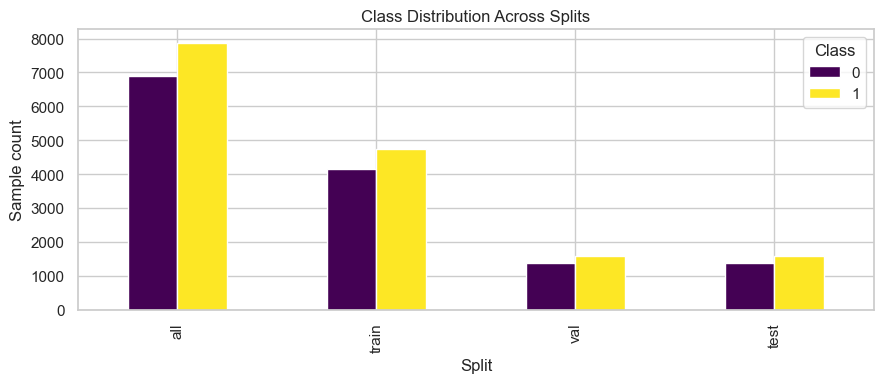

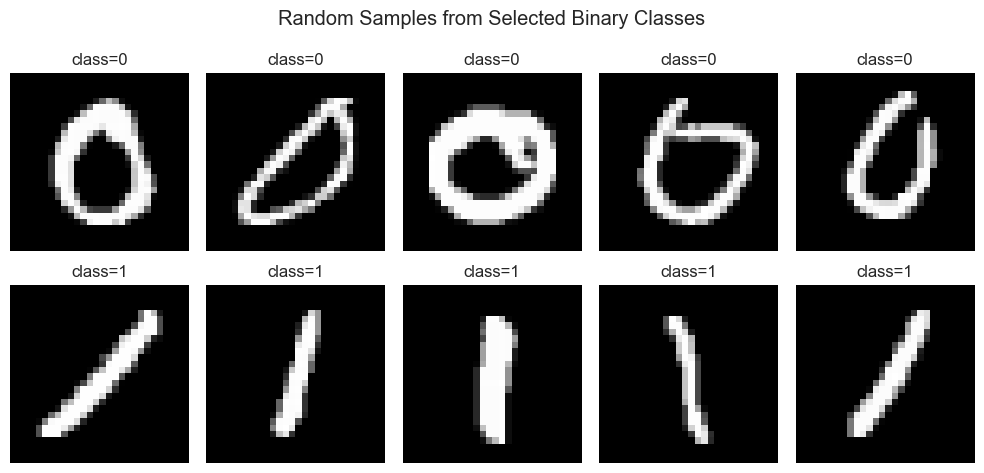

In [4]:
# Visualization checkpoint 1: class balance + sample images
split_df = pd.DataFrame(
    {
        'all': [counts_all.get(CLASS_A, 0), counts_all.get(CLASS_B, 0)],
        'train': [counts_train.get(CLASS_A, 0), counts_train.get(CLASS_B, 0)],
        'val': [counts_val.get(CLASS_A, 0), counts_val.get(CLASS_B, 0)],
        'test': [counts_test.get(CLASS_A, 0), counts_test.get(CLASS_B, 0)],
    },
    index=[CLASS_A, CLASS_B],
)

ax = split_df.T.plot(kind='bar', figsize=(9, 4), colormap='viridis')
ax.set_title('Class Distribution Across Splits')
ax.set_xlabel('Split')
ax.set_ylabel('Sample count')
ax.legend(title='Class')
plt.tight_layout()
plt.show()

rng = np.random.default_rng(RANDOM_STATE)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for row, cls in enumerate([CLASS_A, CLASS_B]):
    cls_idx = np.where(y_binary == cls)[0]
    selected = rng.choice(cls_idx, size=5, replace=False)
    for col, idx in enumerate(selected):
        axes[row, col].imshow(x_binary[idx], cmap='gray')
        axes[row, col].set_title(f'class={cls}')
        axes[row, col].axis('off')

plt.suptitle('Random Samples from Selected Binary Classes')
plt.tight_layout()
plt.show()

In [5]:
summary_rows = []

for mode in FEATURES:
    print(f'Running KNN with feature={mode}')
    result = run_knn_experiment(
        feature_mode=mode,
        x_train=x_train,
        x_val=x_val,
        x_test=x_test,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        class_a=CLASS_A,
        class_b=CLASS_B,
        k_values=K_VALUES,
        pca_components=PCA_COMPONENTS,
        random_state=RANDOM_STATE,
        output_dir=OUTPUT_DIR,
    )
    result['model'] = 'knn'
    summary_rows.append(result)

summary_df = pd.DataFrame(summary_rows).sort_values(
    by=['test_f1_macro', 'test_accuracy'],
    ascending=[False, False],
)
summary_df

Running KNN with feature=flatten
Running KNN with feature=pca
Running KNN with feature=hog


,feature_mode,best_k,class_a,class_b,train_samples,val_samples,test_samples,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,confusion_matrix,model,pca_components_retained,pca_explained_variance
0,flatten,3,0,1,8868,2956,2956,0.994926,0.994762,0.995060,0.994905,"[[1377, 4], [11, 1564]]",knn,NaN,NaN
2,hog,9,0,1,8868,2956,2956,0.993911,0.993842,0.993929,0.993885,"[[1373, 8], [10, 1565]]",knn,NaN,NaN
1,pca,1,0,1,8868,2956,2956,0.993911,0.994350,0.993483,0.993879,"[[1363, 18], [0, 1575]]",knn,96.0,0.950197


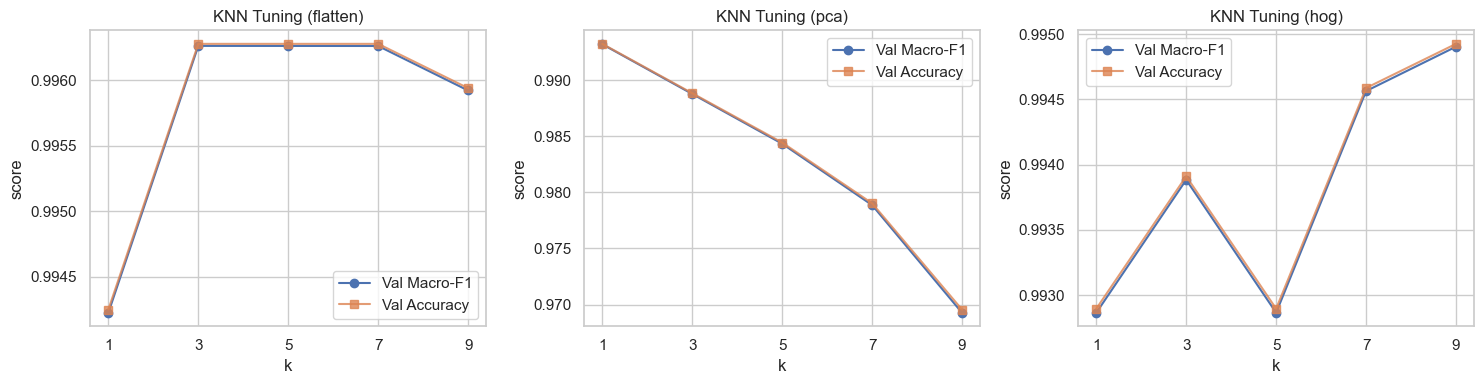

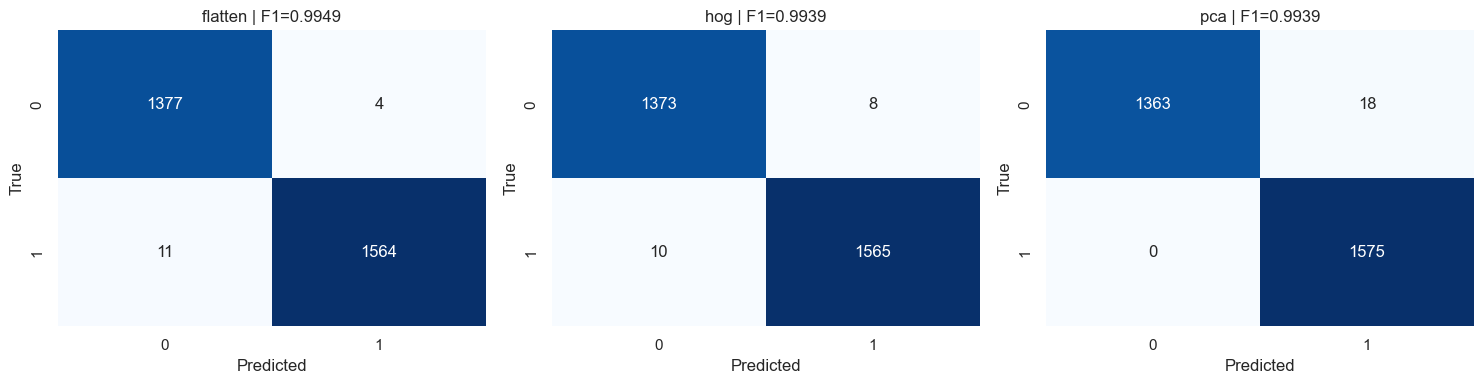

In [ ]:
# Visualization checkpoint 2: tuning curves + confusion matrices
plot_knn_tuning_curves(output_dir=OUTPUT_DIR, feature_modes=FEATURES)
plot_knn_confusion_matrices(summary_df=summary_df, class_a=CLASS_A, class_b=CLASS_B)

In [10]:
summary_df.to_csv(OUTPUT_DIR / 'summary_knn.csv', index=False)

best_knn_raw = summary_df.sort_values(by=['test_f1_macro', 'test_accuracy'], ascending=[False, False]).iloc[0].to_dict()

best_knn = {}
for key, value in best_knn_raw.items():
    if np.isscalar(value) and pd.isna(value):
        best_knn[key] = None
    else:
        best_knn[key] = value

run_info = {
    'class_distribution_all': counts_all,
    'class_distribution_train': counts_train,
    'class_distribution_val': counts_val,
    'class_distribution_test': counts_test,
    'feature_modes': FEATURES,
    'k_values': K_VALUES,
    'test_size': TEST_SIZE,
    'val_size': VAL_SIZE,
    'data_path': DATA_PATH,
    'random_state': RANDOM_STATE,
}

with open(OUTPUT_DIR / 'best_knn.json', 'w', encoding='utf-8') as f:
    json.dump(best_knn, f, indent=2)

with open(OUTPUT_DIR / 'run_info.json', 'w', encoding='utf-8') as f:
    json.dump(run_info, f, indent=2)

print('Saved outputs to:', OUTPUT_DIR)
print('Files: summary_knn.csv, best_knn.json, run_info.json')

Saved outputs to: C:\Users\Ahmed Fahmy\Downloads\Projects\ML\Mnist-Classification\reports\phase1_knn_visual
Files: summary_knn.csv, best_knn.json, run_info.json
